In [2]:
import pandas as pd

movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

print(movies.head())
print(ratings.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [3]:
from sklearn.metrics.pairwise import cosine_similarity

data = pd.merge(ratings, movies, on="movieId")

movie_matrix = data.pivot_table(index="userId", columns="title", values="rating")
movie_matrix = movie_matrix.fillna(0)

similarity = cosine_similarity(movie_matrix.T)

import pandas as pd
similarity_df = pd.DataFrame(similarity,
                             index=movie_matrix.columns,
                             columns=movie_matrix.columns)

def recommend(movie_name):
    similar_movies = similarity_df[movie_name].sort_values(ascending=False)[1:6]
    print("Recommended Movies:")
    for movie in similar_movies.index:
        print(movie)

recommend("Toy Story (1995)")

Recommended Movies:
Toy Story 2 (1999)
Jurassic Park (1993)
Independence Day (a.k.a. ID4) (1996)
Star Wars: Episode IV - A New Hope (1977)
Forrest Gump (1994)


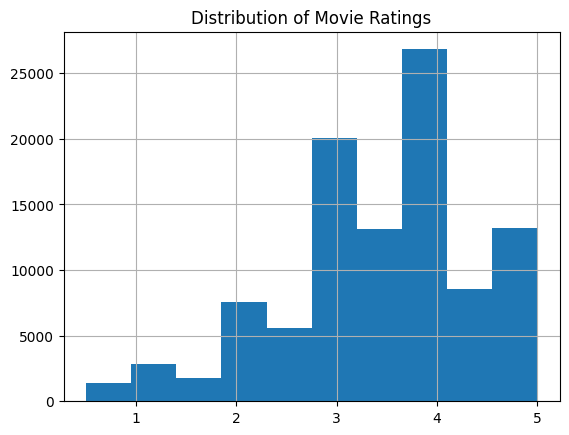

In [4]:
import matplotlib.pyplot as plt

ratings['rating'].hist()
plt.title("Distribution of Movie Ratings")
plt.show()

In [5]:
recommend("Toy Story (1995)")

Recommended Movies:
Toy Story 2 (1999)
Jurassic Park (1993)
Independence Day (a.k.a. ID4) (1996)
Star Wars: Episode IV - A New Hope (1977)
Forrest Gump (1994)


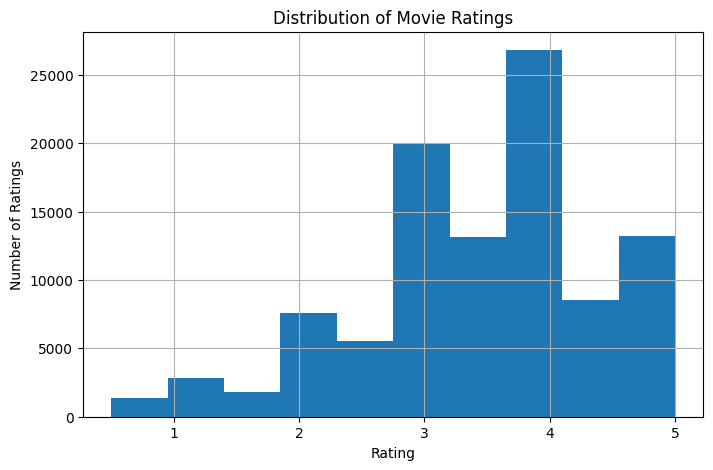

In [6]:
plt.figure(figsize=(8,5))
ratings['rating'].hist()
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.show()

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Replace | with space in genres
movies['genres'] = movies['genres'].str.replace('|',' ')

# Convert text to vectors
cv = CountVectorizer()
genre_matrix = cv.fit_transform(movies['genres'])

# Compute similarity between movies
similarity = cosine_similarity(genre_matrix)

# Create similarity dataframe
similarity_df = pd.DataFrame(similarity,
                             index=movies['title'],
                             columns=movies['title'])

In [8]:
def recommend(movie_name):

    if movie_name not in similarity_df.columns:
        print("Movie not found")
        return

    similar_movies = similarity_df[movie_name].sort_values(ascending=False)[1:6]

    print("Top 5 Recommended Movies:\n")

    for movie in similar_movies.index:
        print(movie)

In [9]:
recommend("Toy Story (1995)")

Top 5 Recommended Movies:

The Good Dinosaur (2015)
Turbo (2013)
Emperor's New Groove, The (2000)
Asterix and the Vikings (Astérix et les Vikings) (2006)
Adventures of Rocky and Bullwinkle, The (2000)
